<a href="https://colab.research.google.com/github/JV-ANUBIS/Sistemas-inteligentes/blob/main/Projeto4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Projeto 4 — Classificação da Ionosfera com Adaline

---

## 📌 Introdução

A ionosfera é uma camada da atmosfera terrestre localizada entre aproximadamente 60 e 1000 km de altitude, caracterizada pela presença de partículas ionizadas devido à radiação solar. Essa região exerce grande influência na propagação de ondas de rádio, sendo essencial para sistemas de telecomunicações e navegação, como o GPS.

O monitoramento da ionosfera pode ser realizado por meio de radares de alta frequência (HF), que emitem sinais e analisam os ecos refletidos. A interpretação desses sinais permite identificar se há presença de estruturas ionosféricas coerentes ou se os sinais atravessam a camada sem reflexão significativa.

Neste projeto, será utilizada a rede neural **Adaline (Adaptive Linear Neuron)** para realizar a classificação automática desses sinais. O objetivo é distinguir entre dois tipos de retorno:

- **+1 (good):** presença de estrutura ionosférica  
- **-1 (bad):** ausência de estrutura, podendo indicar falhas ou interferências

O conjunto de dados utilizado é o *Ionosphere Dataset*, composto por 351 amostras e 34 atributos numéricos, amplamente utilizado em problemas de classificação supervisionada.

---

## 🎯 Objetivo

Aplicar o modelo Adaline na classificação dos sinais da ionosfera, analisando seu desempenho e o impacto da taxa de aprendizagem no processo de convergência.

## ⚙️ Metodologia

Para o desenvolvimento deste projeto, serão realizadas as seguintes etapas:

1. Carregamento e análise inicial do conjunto de dados;
2. Pré-processamento dos dados, incluindo:
   - Conversão dos rótulos para valores numéricos;
   - Remoção de atributos desnecessários;
   - Normalização dos dados utilizando Z-score;
3. Divisão do conjunto em dados de treino e teste;
4. Treinamento do modelo Adaline com diferentes taxas de aprendizagem;
5. Análise da convergência do modelo;
6. Avaliação do desempenho utilizando métricas de classificação.

As implementações serão realizadas utilizando bibliotecas da linguagem Python voltadas para análise de dados e aprendizado de máquina.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

## 📊 Conjunto de Dados

O conjunto de dados utilizado neste projeto é o **Ionosphere Dataset**, disponível no repositório UCI Machine Learning Repository.

Esse dataset foi coletado por um sistema de radar de alta frequência, com o objetivo de analisar a ionosfera. Cada instância representa um sinal de retorno do radar, descrito por 34 atributos numéricos contínuos.

A variável alvo indica se o sinal apresenta estrutura ionosférica coerente ou não:

- **g (good):** presença de estrutura ionosférica  
- **b (bad):** ausência de estrutura (sinal atravessa a ionosfera)

No total, o conjunto possui 351 amostras, sendo:
- 225 da classe *good*
- 126 da classe *bad*

Na etapa de pré-processamento, esses rótulos serão convertidos para valores numéricos bipolares (+1 e -1), conforme exigido pelo modelo Adaline.

In [2]:
# Carregar dataset diretamente da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
df = pd.read_csv(url, header=None)

# Visualizar as primeiras linhas
df.head()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


## 🔄 Preparação dos Dados

Nesta etapa, os dados são organizados para utilização no modelo.

Inicialmente, o conjunto de dados é dividido em:
- **X:** conjunto de atributos (variáveis de entrada)
- **y:** variável alvo (classe)

Em seguida, os rótulos são convertidos de valores categóricos para valores numéricos bipolares, conforme necessário para o funcionamento do modelo Adaline:

- **g → +1**
- **b → -1**

Essa representação é importante, pois o Adaline trabalha com saídas lineares e utiliza funções baseadas em erro numérico para ajuste dos pesos.

In [3]:
# Separar atributos e rótulo
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Converter rótulos para valores numéricos
y = y.map({'g': 1, 'b': -1})

# Verificar distribuição das classes
y.value_counts()

,count
34,
1,225
-1,126


In [4]:
# Verificar valores ausentes
print("Valores ausentes:", X.isnull().sum().sum())

# Remover atributos constantes (não agregam informação)
X = X.loc[:, X.nunique() > 1]

print("Formato após limpeza:", X.shape)

Valores ausentes: 0
Formato após limpeza: (351, 33)


## 📏 Normalização dos Dados

Os dados foram normalizados utilizando a técnica de padronização Z-score, que transforma os atributos para terem média 0 e desvio padrão 1.

Essa etapa é fundamental para o modelo Adaline, pois evita que atributos com escalas maiores dominem o processo de aprendizado, garantindo maior estabilidade na atualização dos pesos durante o treinamento.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [7]:
from sklearn.linear_model import SGDClassifier
import numpy as np

etas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
losses = {}

for eta in etas:
    model = SGDClassifier(
        loss='squared_error',   # equivalente ao Adaline
        learning_rate='constant',
        eta0=eta,
        max_iter=1,
        tol=None,
        random_state=42,
        warm_start=True
    )

    epoch_loss = []

    for epoch in range(200):
        model.fit(X_train, y_train)

        y_pred = model.predict(X_train)
        loss = np.mean((y_train - y_pred)**2)
        epoch_loss.append(loss)

    losses[eta] = epoch_loss

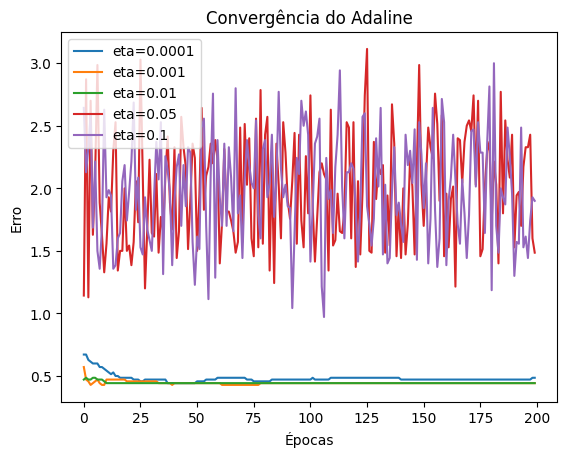

In [8]:
import matplotlib.pyplot as plt

for eta in etas:
    plt.plot(losses[eta], label=f"eta={eta}")

plt.xlabel("Épocas")
plt.ylabel("Erro")
plt.title("Convergência do Adaline")
plt.legend()
plt.show()

In [9]:
best_eta = 0.01

model = SGDClassifier(
    loss='squared_error',
    learning_rate='constant',
    eta0=best_eta,
    max_iter=200,
    tol=None,
    random_state=42
)

model.fit(X_train, y_train)

# Previsão
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("Acurácia:", accuracy_score(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Acurácia: 0.9014084507042254

Matriz de Confusão:
[[20  5]
 [ 2 44]]

Relatório de Classificação:
              precision    recall  f1-score   support

          -1       0.91      0.80      0.85        25
           1       0.90      0.96      0.93        46

    accuracy                           0.90        71
   macro avg       0.90      0.88      0.89        71
weighted avg       0.90      0.90      0.90        71



## 📈 Análise da Taxa de Aprendizagem

A partir dos experimentos realizados com diferentes valores de taxa de aprendizagem (η), foi possível observar comportamentos distintos na convergência do modelo.

Valores mais elevados, como 0.05 e 0.1, apresentaram grande instabilidade, com oscilações significativas na função de perda, indicando dificuldade na convergência.

Por outro lado, valores muito baixos, como 0.0001, apresentaram convergência lenta.

O valor η = 0.01 apresentou o melhor desempenho, com convergência mais rápida e estável, além de atingir menores valores de erro ao longo das épocas. Dessa forma, esse valor foi selecionado para o treinamento final do modelo.

## 📊 Avaliação do Modelo

O modelo Adaline apresentou uma acurácia global de aproximadamente **90,14%**, indicando um bom desempenho na classificação dos sinais da ionosfera.

A matriz de confusão obtida foi:

- Verdadeiros Negativos (TN): 20  
- Falsos Positivos (FP): 5  
- Falsos Negativos (FN): 2  
- Verdadeiros Positivos (TP): 44  

Observa-se que o modelo foi mais eficaz na identificação da classe **good (+1)**, apresentando alto valor de recall (0,96), o que indica que a maioria dos sinais com estrutura ionosférica foi corretamente identificada.

Para a classe **bad (-1)**, o recall foi de 0,80, indicando que alguns casos de ausência de estrutura não foram corretamente detectados.

De forma geral, o modelo apresentou equilíbrio entre precisão e recall, com valores de F1-score elevados para ambas as classes, o que demonstra uma boa capacidade de generalização.

## ⚠️ Análise de Erros de Classificação

Em uma aplicação real de monitoramento da ionosfera, o erro mais crítico é o **falso negativo**.

Esse erro ocorre quando o modelo classifica um sinal como **good (+1)**, quando na realidade ele pertence à classe **bad (-1)**.

Esse tipo de erro é particularmente preocupante, pois indica que o sistema considera a ionosfera estável, quando na verdade há falhas ou interferências. Isso pode comprometer sistemas de comunicação e navegação, como transmissões de rádio e GPS.

Portanto, minimizar falsos negativos é essencial para garantir a confiabilidade do sistema, mesmo que isso implique em um pequeno aumento de falsos positivos.

## 🏁 Conclusão

Neste projeto, foi possível aplicar a rede neural Adaline para a classificação de sinais da ionosfera, utilizando o conjunto de dados Ionosphere. O modelo demonstrou bom desempenho, alcançando uma acurácia superior a 90%, o que indica uma alta capacidade de generalização.

A análise da taxa de aprendizagem mostrou-se fundamental para o sucesso do modelo. Valores elevados resultaram em instabilidade e divergência, enquanto valores muito baixos levaram a uma convergência lenta. O valor intermediário η = 0.01 apresentou o melhor equilíbrio, garantindo uma convergência estável e eficiente.

Além disso, a etapa de normalização dos dados foi essencial para assegurar a estabilidade do processo de treinamento, evitando que atributos com diferentes escalas influenciassem de forma desigual o ajuste dos pesos.

Em relação à aplicação prática, destacou-se a importância de minimizar erros do tipo falso negativo, uma vez que podem levar à interpretação incorreta de condições da ionosfera, comprometendo sistemas de comunicação e navegação.

Por fim, conclui-se que o modelo Adaline é adequado para o problema proposto, apresentando resultados satisfatórios. No entanto, por se tratar de um modelo linear, pode apresentar limitações em cenários mais complexos, o que sugere a possibilidade de utilização de modelos mais avançados em trabalhos futuros.